# Sketchy Dataset — Exploratory Data Analysis

Dataset: Sketchy (Girella et al., ICCV 2025), built on Fashionpedia.  
Task: Multi-label fashion attribute classification.

**Contents**
1. Dataset loading
2. Split overview
3. Sample visualization — outfit vs. single garment
4. Annotation structure
5. Attributes per garment — counts and coverage
6. Attribute vocabulary — supercategories and frequencies
7. Attribute specificity per garment category

## 0. Setup

In [ ]:
import sys
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter, defaultdict
from PIL import Image

sys.path.append('/media/data/mmondo/mmondo/DL_Project/src')
from sketchy.sketchy_dataset import SketchyDataset

DATASET_ROOT = '/media/data/mmondo/mmondo/DL_Project/data/sketchy'
RESULTS_DIR  = '/media/data/mmondo/mmondo/DL_Project/results'

random.seed(42)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

---
## 1. Dataset loading

In [2]:
train_dataset = SketchyDataset(
    dataset_root=DATASET_ROOT, split='train',
    load_img=True, load_local_sketch=True, load_global_sketch=True
)
test_dataset = SketchyDataset(
    dataset_root=DATASET_ROOT, split='test',
    load_img=True, load_local_sketch=True, load_global_sketch=True
)

print(f"Train images : {len(train_dataset):>6,}")
print(f"Test  images : {len(test_dataset):>6,}")

loading annotations into memory...
Done (t=7.20s)
creating index...
index created!
loading attributes...
attributes index created!
creating index...
index created!
loading attributes...
attributes index created!
creating index...
index created!
loading attributes...
attributes index created!
loading annotations into memory...
Done (t=0.13s)
creating index...
index created!
loading attributes...
attributes index created!
creating index...
index created!
loading attributes...
attributes index created!
creating index...
index created!
loading attributes...
attributes index created!
Train images : 45,585
Test  images :  1,158


---
## 2. Split overview

                               Train       Test
Images                        45,585      1,158
Total garment annotations     77,015      2,037
Annotations/image — mean        1.69       1.76
Annotations/image — min            1          1
Annotations/image — max            6          5
Single-garment images         22,886        493
Outfit images (≥2 garments)     22,699        665


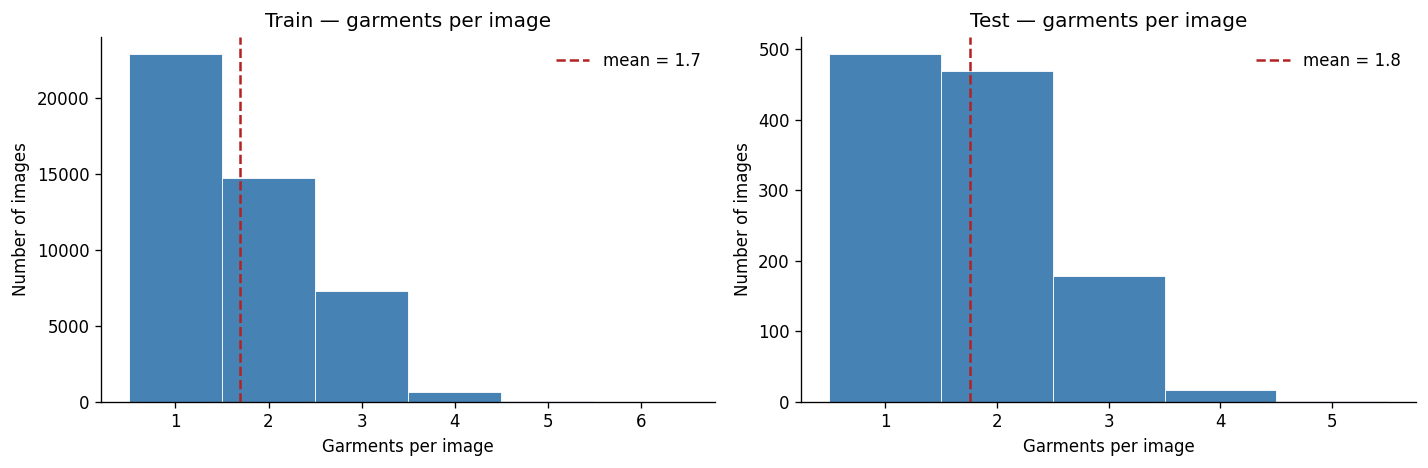

In [3]:
# Collect annotations-per-image counts for both splits
def ann_counts(dataset):
    return [len(dataset[i]['annotations']) for i in range(len(dataset))]

train_ann = np.array(ann_counts(train_dataset))
test_ann  = np.array(ann_counts(test_dataset))

total_train_anns = train_ann.sum()
total_test_anns  = test_ann.sum()

print("=" * 50)
print(f"{'':25} {'Train':>10} {'Test':>10}")
print("=" * 50)
print(f"{'Images':25} {len(train_dataset):>10,} {len(test_dataset):>10,}")
print(f"{'Total garment annotations':25} {total_train_anns:>10,} {total_test_anns:>10,}")
print(f"{'Annotations/image — mean':25} {train_ann.mean():>10.2f} {test_ann.mean():>10.2f}")
print(f"{'Annotations/image — min':25} {train_ann.min():>10} {test_ann.min():>10}")
print(f"{'Annotations/image — max':25} {train_ann.max():>10} {test_ann.max():>10}")
print(f"{'Single-garment images':25} {(train_ann == 1).sum():>10,} {(test_ann == 1).sum():>10,}")
print(f"{'Outfit images (≥2 garments)':25} {(train_ann >= 2).sum():>10,} {(test_ann >= 2).sum():>10,}")
print("=" * 50)

# Distribution of annotations per image
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, data, split in zip(axes, [train_ann, test_ann], ['Train', 'Test']):
    bins = range(1, data.max() + 2)
    ax.hist(data, bins=bins, edgecolor='white', linewidth=0.5, color='steelblue', align='left')
    ax.set_xlabel('Garments per image')
    ax.set_ylabel('Number of images')
    ax.set_title(f'{split} — garments per image')
    ax.axvline(data.mean(), color='firebrick', linewidth=1.5, linestyle='--', label=f'mean = {data.mean():.1f}')
    ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/split_overview.png', bbox_inches='tight')
plt.show()

---
## 3. Sample visualization

One **outfit** sample (≥ 2 garments) and one **single-garment** sample, each shown with the real image, one garment sketch, and its textual description.

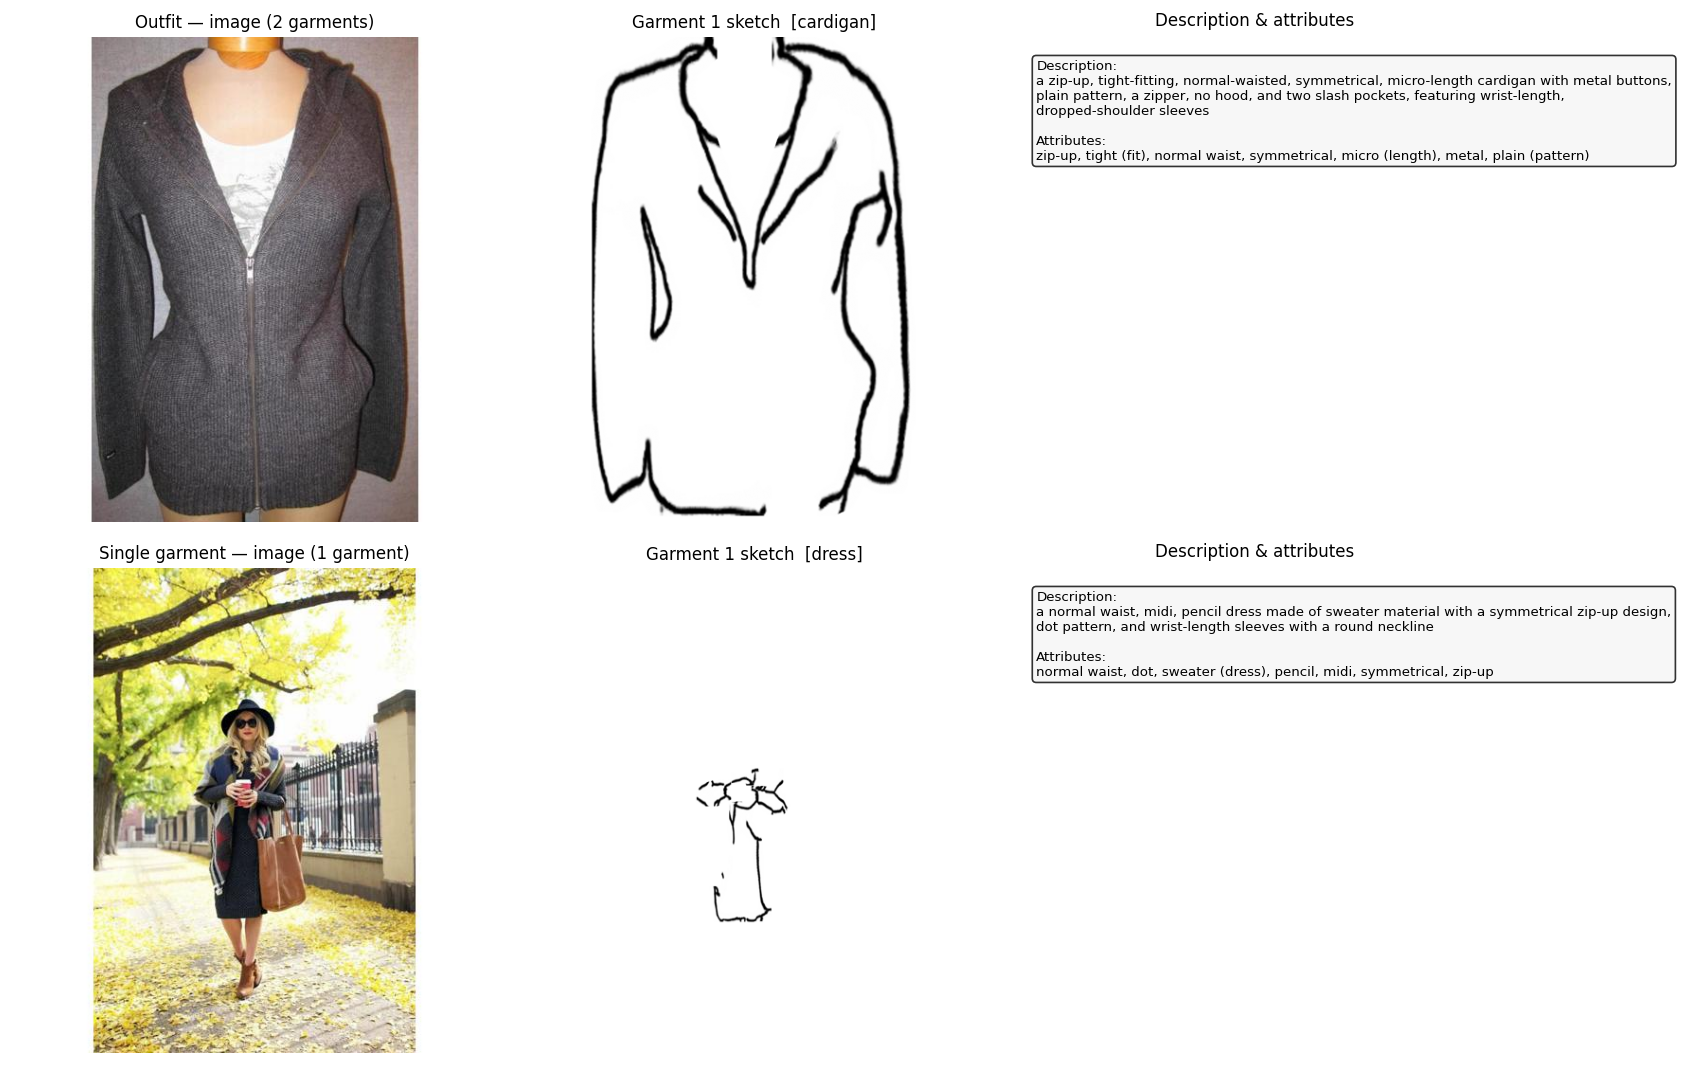

In [4]:
def find_sample(dataset, multi_garment: bool):
    """Return index of a random sample matching single/multi-garment criterion."""
    candidates = [
        i for i in range(len(dataset))
        if (len(dataset[i]['annotations']) >= 2) == multi_garment
    ]
    return random.choice(candidates)

outfit_idx  = find_sample(train_dataset, multi_garment=True)
single_idx  = find_sample(train_dataset, multi_garment=False)

def show_sample(ax_row, sample, title_prefix):
    anns  = sample['annotations']
    img   = sample['image'] if isinstance(sample['image'], Image.Image) else Image.open(sample['image'])
    sketch = sample['local_sketches'][0] if isinstance(sample['local_sketches'][0], Image.Image) \
             else Image.open(sample['local_sketches'][0])
    desc  = sample['local_descriptions'][0]
    attrs = anns[0].get('top_level') or []

    # image
    ax_row[0].imshow(img)
    ax_row[0].set_title(f'{title_prefix} — image ({len(anns)} garment{"s" if len(anns)>1 else ""})', fontsize=10)
    ax_row[0].axis('off')

    # sketch of first garment
    ax_row[1].imshow(sketch.convert('L'), cmap='gray')
    ax_row[1].set_title(f'Garment 1 sketch  [{anns[0]["category_name"]}]', fontsize=10)
    ax_row[1].axis('off')

    # description + attributes
    attr_str = ', '.join(attrs) if attrs else '(none)'
    text = f"Description:\n{desc}\n\nAttributes:\n{attr_str}"
    ax_row[2].text(0.05, 0.95, text, transform=ax_row[2].transAxes,
                   va='top', ha='left', fontsize=8, wrap=True,
                   bbox=dict(boxstyle='round', facecolor='#f5f5f5', alpha=0.8))
    ax_row[2].set_title('Description & attributes', fontsize=10)
    ax_row[2].axis('off')

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
show_sample(axes[0], train_dataset[outfit_idx],  'Outfit')
show_sample(axes[1], train_dataset[single_idx], 'Single garment')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/sample_visualization.png', bbox_inches='tight')
plt.show()

---
## 4. Annotation structure

One annotation = one garment in one image.

In [5]:
import pprint

sample = train_dataset[outfit_idx]
ann    = sample['annotations'][0]

# Pretty-print with truncated segmentation to keep output readable
display_ann = {k: (v[:3] if k == 'segmentation' and isinstance(v, list) and len(v) > 3 else v)
               for k, v in ann.items()}
if 'segmentation' in display_ann:
    display_ann['segmentation'] = str(display_ann['segmentation']) + ' ... (truncated)'

print("Keys in a sample dict:")
print([k for k in sample.keys()])
print()
print("Keys in one annotation:")
print([k for k in ann.keys()])
print()
print("Example annotation:")
pprint.pprint(display_ann, width=100)

Keys in a sample dict:
['image_id', 'img_data', 'annotations', 'global_sketch_path', 'local_descriptions', 'local_descriptions_ann_ids', 'global_description', 'local_sketches_paths', 'global_sketch', 'local_sketches', 'image_path', 'image']

Keys in one annotation:
['image_id', 'category_id', 'attribute_ids', 'segmentation', 'bbox', 'area', 'iscrowd', 'id', 'padding', 'final_height', 'final_width', 'cropping', 'filename', 'top_level', 'sub_level', 'category_name', 'description']

Example annotation:
{'area': 507751,
 'attribute_ids': [229, 135, 142, 115, 148, 283, 316, 317],
 'bbox': [1.0, 20.0, 664.0, 991.0],
 'category_id': 3,
 'category_name': 'cardigan',
 'cropping': [0, 0, 512, 512],
 'description': 'A zip-up, tight-fitting, normal-waisted, symmetrical, micro-length cardigan with '
                'metal buttons, plain pattern, a zipper, no hood, and two slash pockets, featuring '
                'wrist-length, dropped-shoulder sleeves',
 'filename': '197642.jpg',
 'final_height':

---
## 5. Attributes per garment — counts and coverage

Total garment annotations: 77,015
  with 0 attributes :    199  (0.3%)
  with ≥1 attribute : 76,816  (99.7%)

Attributes per garment:
  mean   : 6.19
  median : 6
  std    : 1.73
  min    : 0
  max    : 14


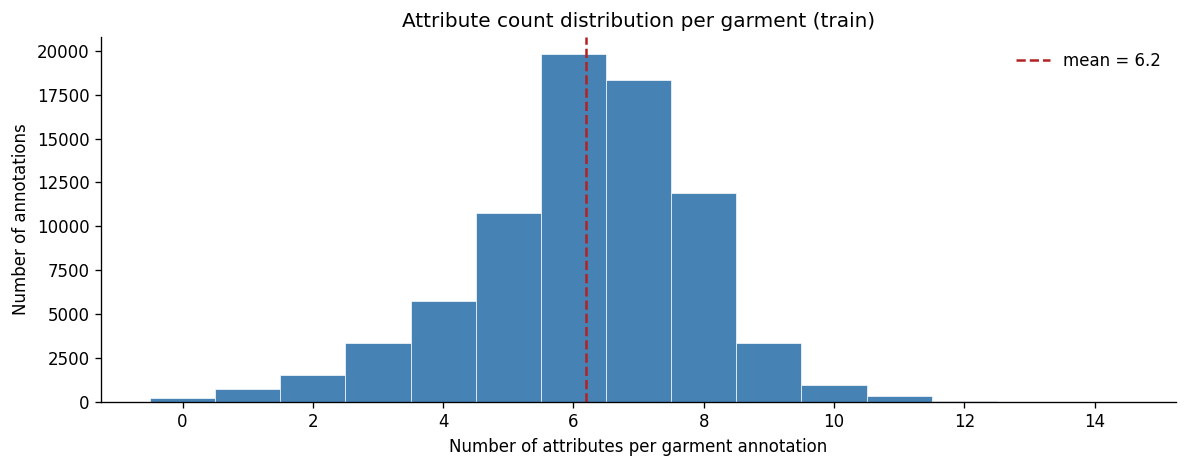

In [6]:
attr_counts_per_ann = []  # number of top_level attributes per annotation

for idx in range(len(train_dataset)):
    sample = train_dataset[idx]
    for ann in sample['annotations']:
        n = len(ann['top_level']) if ann.get('top_level') else 0
        attr_counts_per_ann.append(n)

attr_counts_per_ann = np.array(attr_counts_per_ann)
n_ann = len(attr_counts_per_ann)

print(f"Total garment annotations: {n_ann:,}")
print(f"  with 0 attributes : {(attr_counts_per_ann == 0).sum():>6,}  ({(attr_counts_per_ann == 0).mean()*100:.1f}%)")
print(f"  with ≥1 attribute : {(attr_counts_per_ann >= 1).sum():>6,}  ({(attr_counts_per_ann >= 1).mean()*100:.1f}%)")
print()
print(f"Attributes per garment:")
print(f"  mean   : {attr_counts_per_ann.mean():.2f}")
print(f"  median : {np.median(attr_counts_per_ann):.0f}")
print(f"  std    : {attr_counts_per_ann.std():.2f}")
print(f"  min    : {attr_counts_per_ann.min()}")
print(f"  max    : {attr_counts_per_ann.max()}")

fig, ax = plt.subplots(figsize=(10, 4))
bins = range(0, attr_counts_per_ann.max() + 2)
ax.hist(attr_counts_per_ann, bins=bins, edgecolor='white', linewidth=0.4, color='steelblue', align='left')
ax.axvline(attr_counts_per_ann.mean(), color='firebrick', linewidth=1.5, linestyle='--',
           label=f'mean = {attr_counts_per_ann.mean():.1f}')
ax.set_xlabel('Number of attributes per garment annotation')
ax.set_ylabel('Number of annotations')
ax.set_title('Attribute count distribution per garment (train)')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/attrs_per_garment.png', bbox_inches='tight')
plt.show()

---
## 6. Attribute vocabulary — supercategories and frequencies

Fashionpedia defines 294 attributes grouped into 11 supercategories.

In [7]:
all_attrs = train_dataset.fp.dataset['attributes']
attr_id_to_meta = {a['id']: a for a in all_attrs}

# Supercategory summary from vocabulary
supercat_counter = Counter(a['supercategory'] for a in all_attrs)
examples_by_sc   = {}
for a in all_attrs:
    sc = a['supercategory']
    if sc not in examples_by_sc:
        examples_by_sc[sc] = a['name']

print(f"Total attributes in vocabulary: {len(all_attrs)}")
print()
print(f"{'Supercategory':<48} {'# attrs':>8}   Example attribute")
print("-" * 80)
for sc, cnt in supercat_counter.most_common():
    print(f"  {sc:<46} {cnt:>8}   {examples_by_sc[sc]}")

Total attributes in vocabulary: 294

Supercategory                                     # attrs   Example attribute
--------------------------------------------------------------------------------
  nickname                                            153   classic (t-shirt)
  silhouette                                           25   asymmetrical
  neckline type                                        25   collarless
  textile finishing, manufacturing techniques          21   burnout
  textile pattern                                      18   plain (pattern)
  length                                               15   above-the-hip (length)
  opening type                                         10   single breasted
  non-textile material type                            10   plastic
  waistline                                             7   empire waistline
  animal                                                6   leopard
  leather                                               4   suede


In [8]:
# Count actual occurrences of each attribute in the train split
attr_occ_counter   = Counter()  # by attribute name
sc_occ_counter     = Counter()  # by supercategory
attr_name_to_sc    = {a['name']: a['supercategory'] for a in all_attrs}

for idx in range(len(train_dataset)):
    sample = train_dataset[idx]
    for ann in sample['annotations']:
        for label in (ann.get('top_level') or []):
            attr_occ_counter[label] += 1
            sc_occ_counter[attr_name_to_sc.get(label, 'unknown')] += 1

total_occ = sum(attr_occ_counter.values())
print(f"Total attribute occurrences in train: {total_occ:,}")
print(f"Unique attributes observed           : {len(attr_occ_counter)} / {len(all_attrs)} in vocabulary")
print()

# Per-supercategory breakdown: vocab size, observed attrs, occurrences, share
sc_vocab_size = Counter(a['supercategory'] for a in all_attrs)
sc_observed   = defaultdict(set)
for label, sc in attr_name_to_sc.items():
    if label in attr_occ_counter:
        sc_observed[sc].add(label)

print(f"{'Supercategory':<48} {'vocab':>6} {'seen':>6} {'occ':>10} {'share':>7}")
print("-" * 82)
for sc, occ in sc_occ_counter.most_common():
    print(f"  {sc:<46} {sc_vocab_size[sc]:>6} {len(sc_observed[sc]):>6} "
          f"{occ:>10,} {occ/total_occ*100:>6.1f}%")

Total attribute occurrences in train: 476,716
Unique attributes observed           : 238 / 294 in vocabulary

Supercategory                                     vocab   seen        occ   share
----------------------------------------------------------------------------------
  silhouette                                         25     25    132,511   27.8%
  textile pattern                                    18     18     75,715   15.9%
  length                                             15     13     65,611   13.8%
  waistline                                           7      7     60,560   12.7%
  nickname                                          153    118     49,859   10.5%
  opening type                                       10     10     44,738    9.4%
  textile finishing, manufacturing techniques        21     20     40,897    8.6%
  non-textile material type                          10      9      6,003    1.3%
  animal                                              6      6       

/tmp/ipykernel_864141/2287223467.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap     = plt.cm.get_cmap('tab20', len(sc_list))


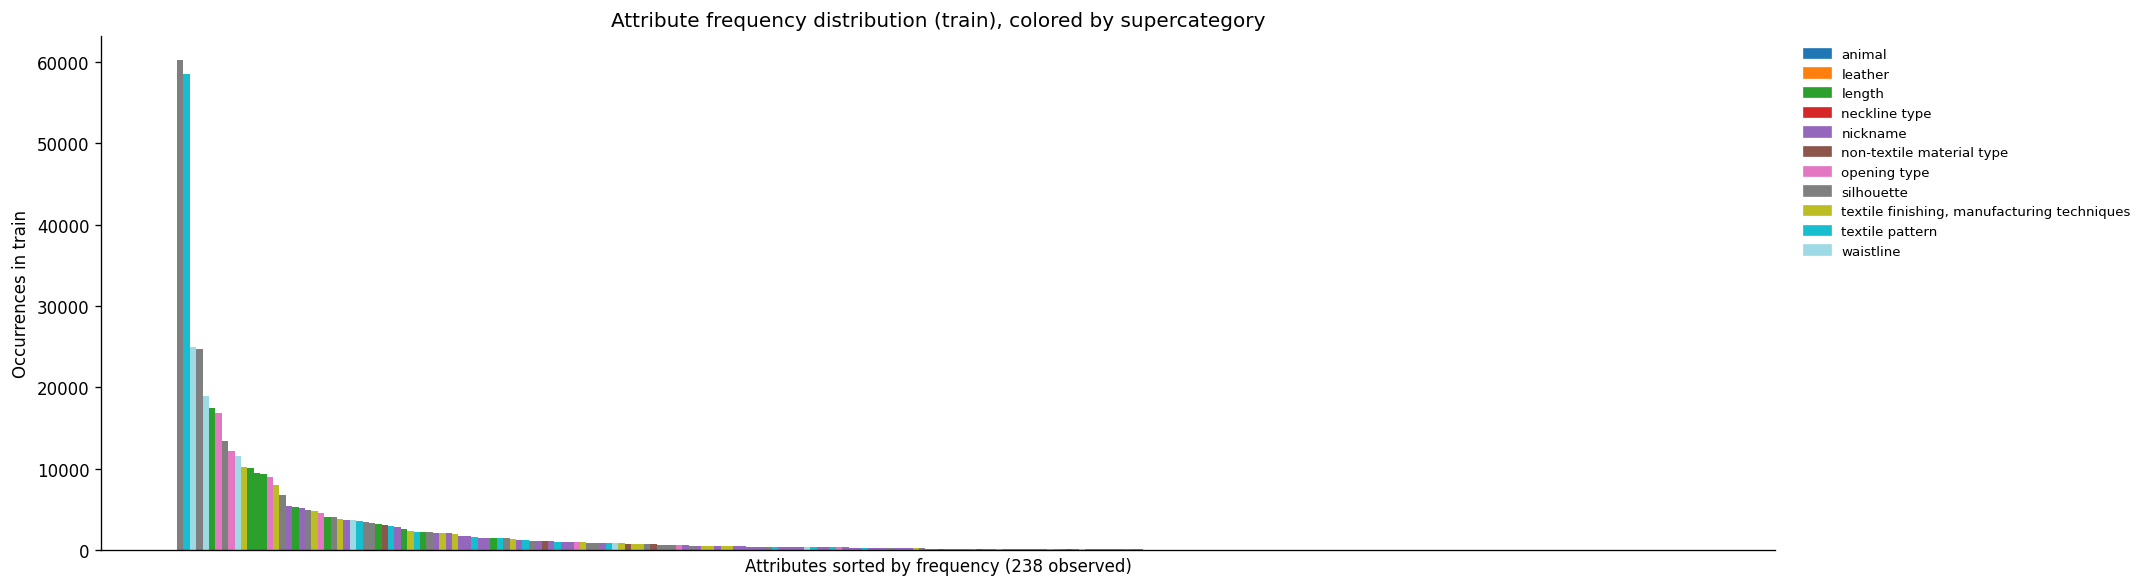

/tmp/ipykernel_864141/2287223467.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top_labels, rotation=45, ha='right', fontsize=9)


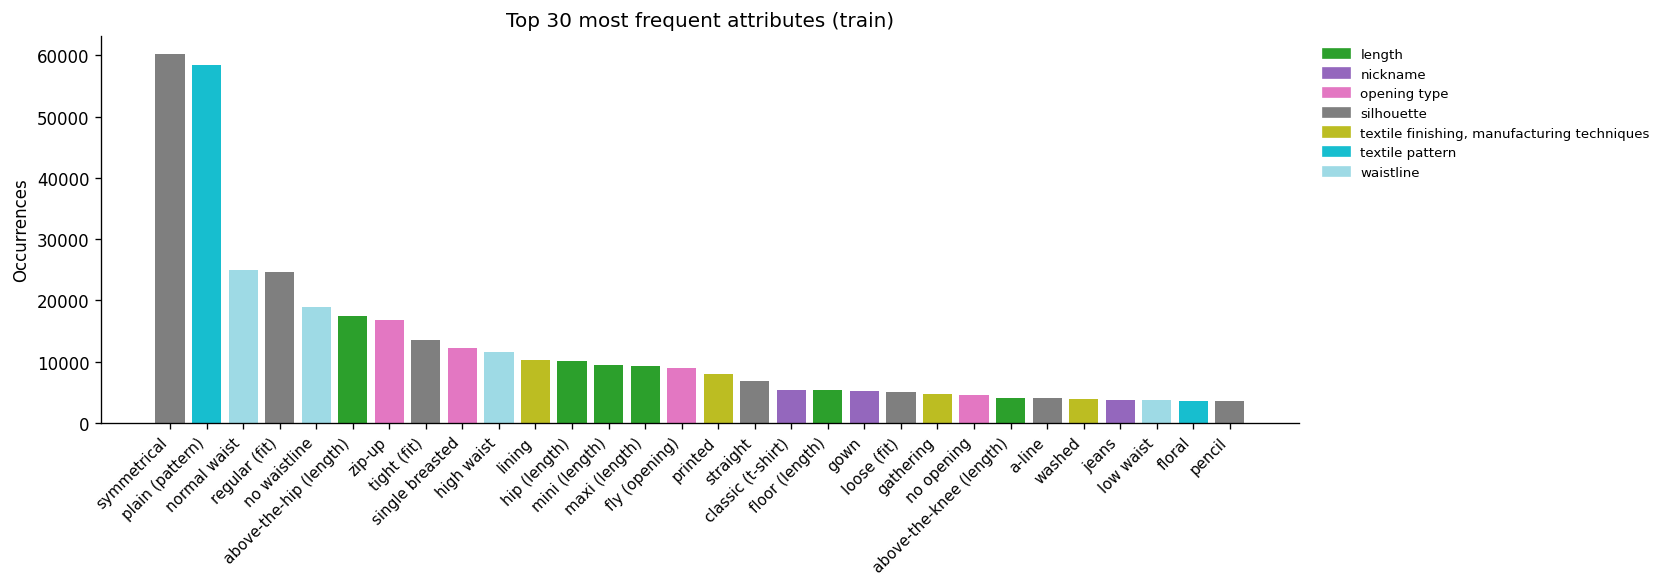

In [9]:
# Bar chart of all observed attributes, colored by supercategory
sorted_attrs = sorted(attr_occ_counter.items(), key=lambda x: x[1], reverse=True)
labels_all, counts_all = zip(*sorted_attrs)

sc_list  = list({attr_name_to_sc.get(l, 'unknown') for l in labels_all})
sc_list.sort()
cmap     = plt.cm.get_cmap('tab20', len(sc_list))
sc_color = {sc: cmap(i) for i, sc in enumerate(sc_list)}
colors   = [sc_color[attr_name_to_sc.get(l, 'unknown')] for l in labels_all]

fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(range(len(labels_all)), counts_all, color=colors, width=1.0)
ax.set_xticks([])
ax.set_xlabel(f'Attributes sorted by frequency ({len(labels_all)} observed)')
ax.set_ylabel('Occurrences in train')
ax.set_title('Attribute frequency distribution (train), colored by supercategory')

legend_patches = [mpatches.Patch(color=sc_color[sc], label=sc) for sc in sc_list]
ax.legend(handles=legend_patches, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, frameon=False)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/attr_frequency.png', bbox_inches='tight')
plt.show()

# Top-30 named chart
TOP = 30
fig, ax = plt.subplots(figsize=(14, 5))
top_labels = labels_all[:TOP]
top_counts = counts_all[:TOP]
top_colors = [sc_color[attr_name_to_sc.get(l, 'unknown')] for l in top_labels]
ax.bar(top_labels, top_counts, color=top_colors)
ax.set_xticklabels(top_labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Occurrences')
ax.set_title(f'Top {TOP} most frequent attributes (train)')
legend_scs = sorted({attr_name_to_sc.get(l, 'unknown') for l in top_labels})
ax.legend(handles=[mpatches.Patch(color=sc_color[sc], label=sc) for sc in legend_scs],
          bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, frameon=False)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/attr_top30.png', bbox_inches='tight')
plt.show()

---
## 7. Attribute specificity per garment category

For each (attribute, garment category) pair we compute the **specificity score**: fraction of that attribute's total occurrences that fall in this category. A score close to 1 means the attribute is nearly exclusive to that category.

In [10]:
# co-occurrence matrix: attr_name × category_name
attr_cat_counts = defaultdict(lambda: defaultdict(int))  # attr → cat → count
cat_set         = set()

for idx in range(len(train_dataset)):
    sample = train_dataset[idx]
    for ann in sample['annotations']:
        cat = ann['category_name']
        cat_set.add(cat)
        for label in (ann.get('top_level') or []):
            attr_cat_counts[label][cat] += 1

cats_sorted = sorted(cat_set)
print(f"Garment categories in train: {len(cats_sorted)}")
print(cats_sorted)

# Category-level summary
cat_ann_counter = Counter()
for idx in range(len(train_dataset)):
    for ann in train_dataset[idx]['annotations']:
        cat_ann_counter[ann['category_name']] += 1

print()
print(f"{'Category':<25} {'Annotations':>12}")
print("-" * 40)
for cat, cnt in cat_ann_counter.most_common():
    print(f"  {cat:<23} {cnt:>12,}")

Garment categories in train: 13
['cape', 'cardigan', 'coat', 'dress', 'jacket', 'jumpsuit', 'pants', 'shirt, blouse', 'shorts', 'skirt', 'sweater', 'top, t-shirt, sweatshirt', 'vest']

Category                   Annotations
----------------------------------------
  dress                         18,739
  top, t-shirt, sweatshirt       16,548
  pants                         12,414
  jacket                         7,833
  shirt, blouse                  6,161
  skirt                          5,046
  coat                           3,124
  shorts                         2,756
  sweater                        1,494
  cardigan                       1,107
  jumpsuit                         922
  vest                             719
  cape                             152


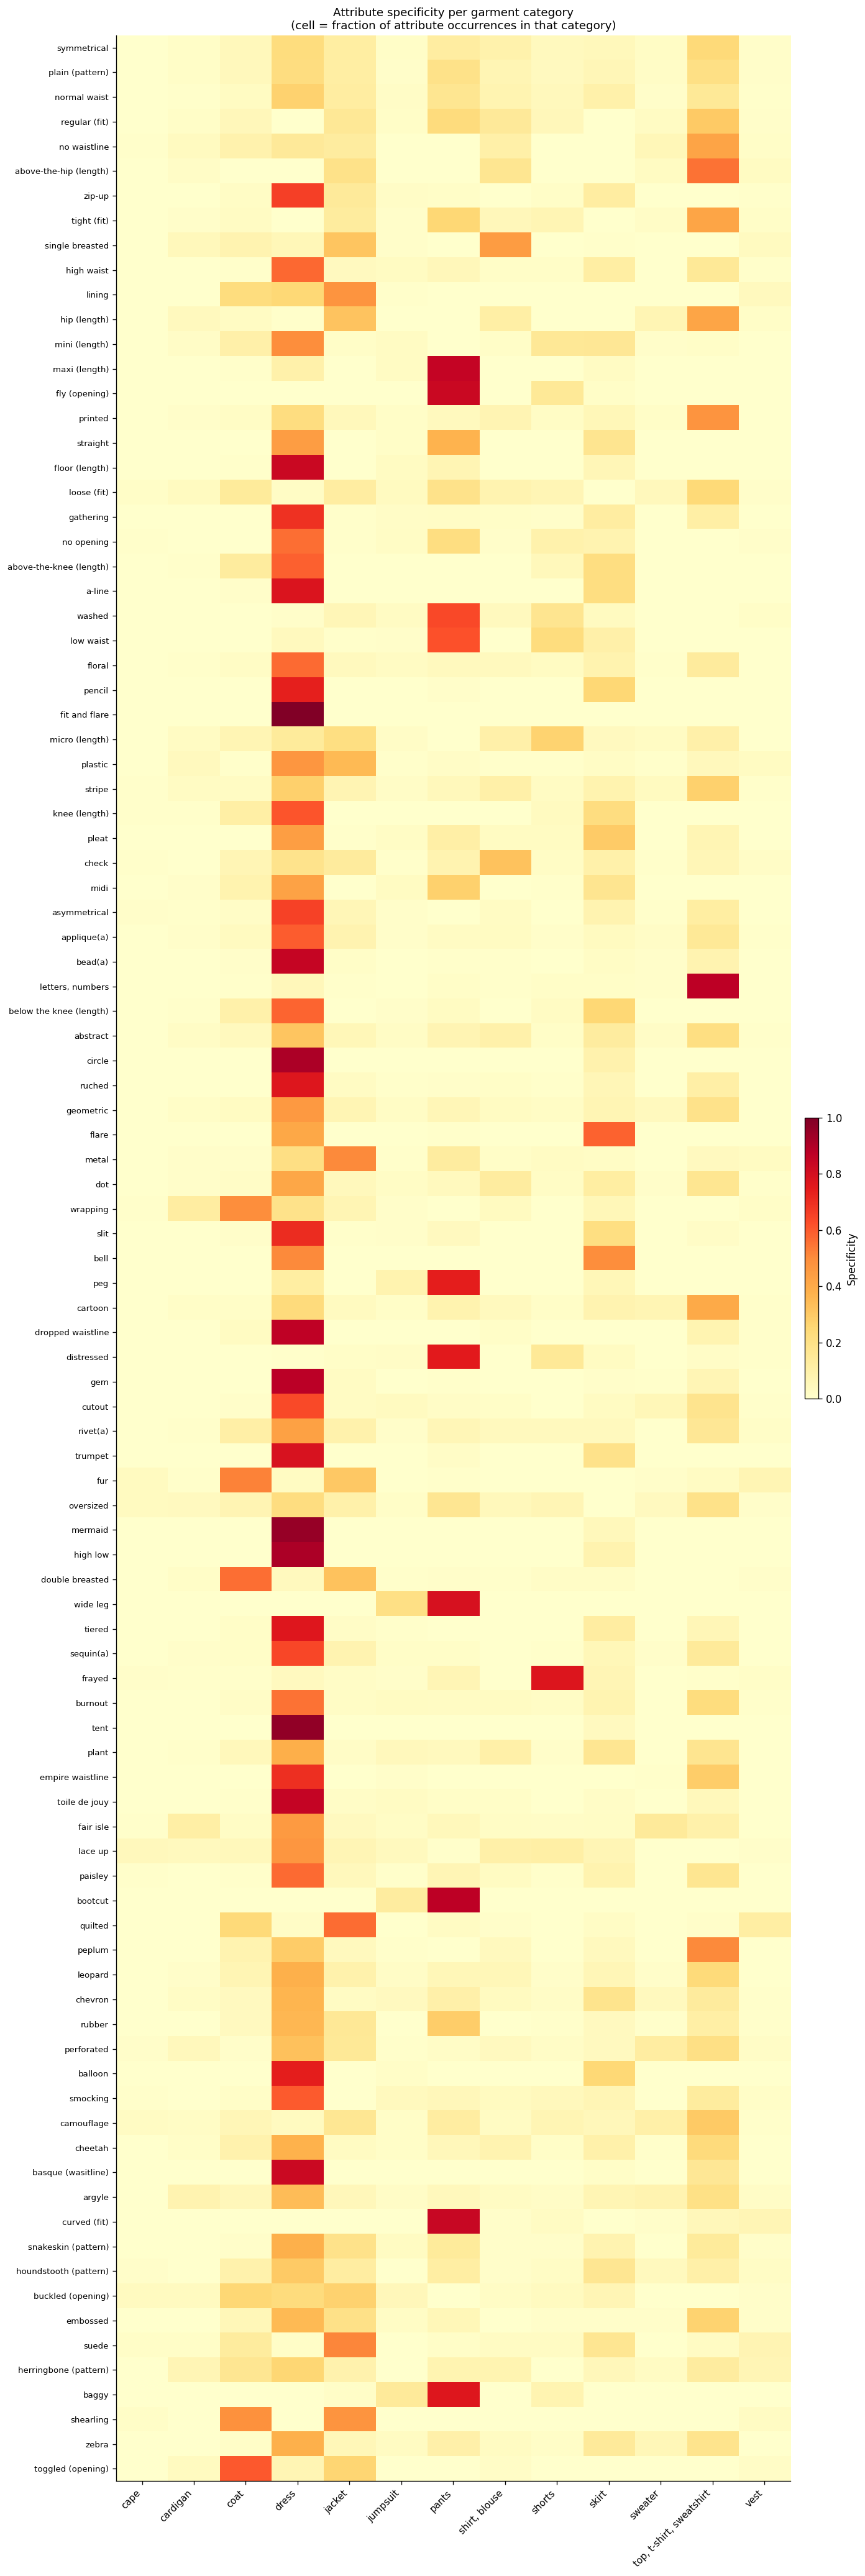

In [11]:
# Restrict to non-nickname attributes with ≥ 50 occurrences for a clean heatmap
nickname_attrs = {a['name'] for a in all_attrs if a['supercategory'] == 'nickname'}
common_attrs   = [l for l in labels_all if l not in nickname_attrs and attr_occ_counter[l] >= 50]

# Build specificity matrix: attr × cat
# specificity[i, j] = count(attr_i in cat_j) / total_count(attr_i)
n_attr = len(common_attrs)
n_cat  = len(cats_sorted)
spec_matrix = np.zeros((n_attr, n_cat))

for i, attr in enumerate(common_attrs):
    total = sum(attr_cat_counts[attr].values())
    for j, cat in enumerate(cats_sorted):
        spec_matrix[i, j] = attr_cat_counts[attr].get(cat, 0) / total

fig, ax = plt.subplots(figsize=(max(10, n_cat * 0.9), max(8, n_attr * 0.35)))
im = ax.imshow(spec_matrix, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(n_cat))
ax.set_xticklabels(cats_sorted, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(n_attr))
ax.set_yticklabels(common_attrs, fontsize=8)
ax.set_title('Attribute specificity per garment category\n'
             '(cell = fraction of attribute occurrences in that category)', fontsize=11)
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02, label='Specificity')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/attr_specificity_heatmap.png', bbox_inches='tight')
plt.show()

In [12]:
# Highly specific attributes: those where ≥ 70% of occurrences are in a single category
THRESHOLD = 0.70
print(f"Attributes with ≥{THRESHOLD*100:.0f}% of occurrences in a single garment category:\n")
print(f"{'Attribute':<35} {'Category':<25} {'Specificity':>12} {'Total occ':>10}")
print("-" * 85)

rows = []
for i, attr in enumerate(common_attrs):
    max_spec = spec_matrix[i].max()
    if max_spec >= THRESHOLD:
        dominant_cat = cats_sorted[spec_matrix[i].argmax()]
        rows.append((max_spec, attr, dominant_cat, attr_occ_counter[attr]))

for spec, attr, cat, occ in sorted(rows, reverse=True):
    print(f"  {attr:<33} {cat:<25} {spec:>11.1%} {occ:>10,}")

Attributes with ≥70% of occurrences in a single garment category:

Attribute                           Category                   Specificity  Total occ
-------------------------------------------------------------------------------------
  fit and flare                     dress                           99.5%      3,408
  tent                              dress                           96.2%        444
  mermaid                           dress                           95.2%        669
  circle                            dress                           90.9%      1,462
  high low                          dress                           90.8%        663
  gem                               dress                           87.5%        793
  letters, numbers                  top, t-shirt, sweatshirt        87.3%      1,674
  bootcut                           pants                           87.2%        257
  dropped waistline                 dress                           86.4%        